In [1]:
import qiskit
print(qiskit.__version__)

1.3.2


# AML23703 – Quantum Computing

# Tutorial 2: Qubits, State Vectors and Superposition Visualization

---

**Name:** Mythri M R

**USN:** 1GA23AI027

**Department:** Artificial Intelligence and Machine Learning

**Semester:** VII

**Course Code:** AML23703

**Date:** 30-07-2026

## Objective

The objective of this tutorial is to understand qubits, represent quantum states using state vectors and Dirac notation, create superposition states, visualize quantum states using the Bloch Sphere and Q-Sphere, and verify quantum state normalization using Qiskit.

## Theory

A qubit is the fundamental unit of quantum information. Unlike a classical bit, which can only exist in the state 0 or 1, a qubit can exist in a superposition of both states simultaneously.

The state of a qubit is mathematically represented using a **state vector**. Quantum gates such as the Pauli-X, Hadamard (H), and Phase (S) gates manipulate the state of a qubit.

The **Bloch Sphere** provides a geometric representation of a single qubit, while the **Q-Sphere** is useful for visualizing multi-qubit quantum states.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import (
    plot_bloch_multivector,
    plot_state_qsphere
)
print("Libraries Imported Successfully")


Libraries Imported Successfully


# Exercise 1 Easy

## Creating a Qubit and Applying the X Gate

Quantum Circuit after applying X Gate


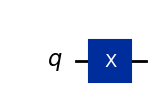

In [3]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from IPython.display import display
qc = QuantumCircuit(1)
qc.x(0)
print("Quantum Circuit after applying X Gate")
display(qc.draw("mpl"))


In [4]:
state = Statevector.from_instruction(qc)
print("State Vector")
print(state)


State Vector
Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


### Observation

The Pauli-X gate flips the qubit from the |0⟩ state to the |1⟩ state.
The state vector confirms that the probability of measuring the qubit in state |1⟩ is 100%.












###

# Exercise 2 Medium

## Hadamard Gate and Phase Gate

Quantum Circuit


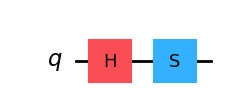

In [5]:
from qiskit import QuantumCircuit
from IPython.display import display
qc2 = QuantumCircuit(1)
qc2.h(0)
qc2.s(0)
print("Quantum Circuit")
display(qc2.draw("mpl"))


In [6]:
state2 = Statevector.from_instruction(qc2)
print("State Vector")
print(state2)

State Vector
Statevector([0.70710678+0.j        , 0.        +0.70710678j],
            dims=(2,))


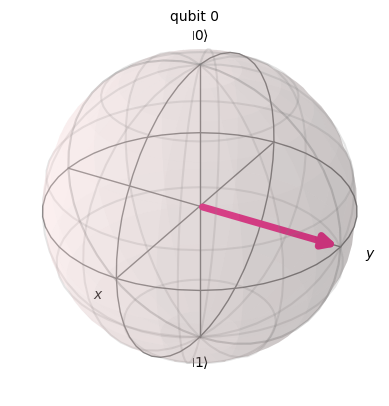

In [7]:
from qiskit.visualization import plot_bloch_multivector
plot_bloch_multivector(state2)


### Observation

The Hadamard gate creates an equal superposition of the |0⟩ and |1⟩ states.

The S gate introduces a phase shift without changing the measurement probabilities.

The Bloch Sphere clearly illustrates the change in the qubit's orientation after the phase gate is applied.
















###



# Exercise 3 Hard

## Two-Qubit Equal Superposition

Quantum Circuit


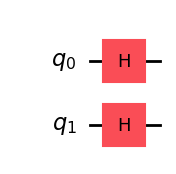

In [8]:
qc3 = QuantumCircuit(2)
qc3.h(0)
qc3.h(1)
print("Quantum Circuit")
display(qc3.draw("mpl"))


In [9]:
state3 = Statevector.from_instruction(qc3)
print("State Vector")
print(state3)


State Vector
Statevector([0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j],
            dims=(2, 2))


### Explanation

Each basis state has the same amplitude (0.5), which means the quantum system is equally likely to collapse into any one of the four basis states after measurement.

###

In [10]:
probabilities = np.abs(state3.data)**2
print("Probability of each basis state")
for state, prob in zip(["|00⟩","|01⟩","|10⟩","|11⟩"], probabilities):
    print(f"{state}: {prob:.2f}")
print("\nTotal Probability =", probabilities.sum())


Probability of each basis state
|00⟩: 0.25
|01⟩: 0.25
|10⟩: 0.25
|11⟩: 0.25

Total Probability = 0.9999999999999996


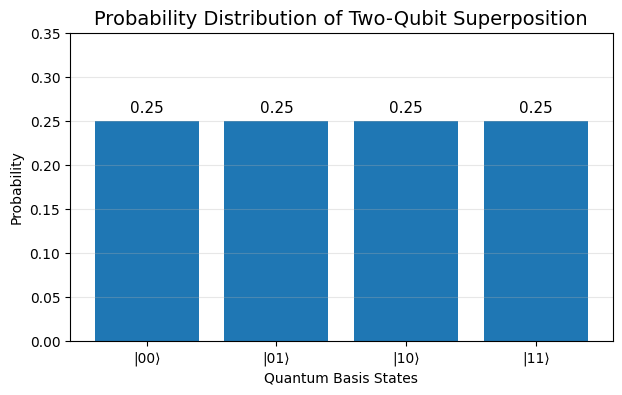

In [11]:
states = ["|00⟩","|01⟩","|10⟩","|11⟩"]
plt.figure(figsize=(7,4))
bars = plt.bar(states, probabilities)
plt.title("Probability Distribution of Two-Qubit Superposition",
          fontsize=14)
plt.xlabel("Quantum Basis States")
plt.ylabel("Probability")
plt.ylim(0,0.35)
plt.grid(axis='y', alpha=0.3)
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,
             y+0.01,
             f"{y:.2f}",
             ha='center',
             fontsize=11)
plt.show()


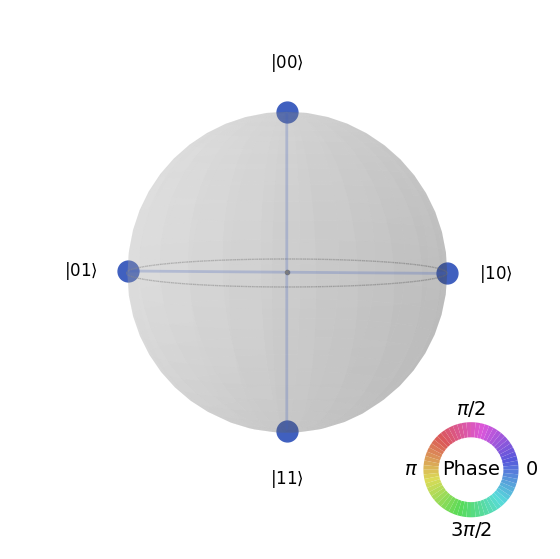

In [12]:
from qiskit.visualization import plot_state_qsphere
fig = plot_state_qsphere(state3)
display(fig)


### Observation

The Hadamard gates placed both qubits into an equal superposition.

Each of the four basis states has an equal probability of 0.25.

The probability values sum to 1, satisfying the normalization condition of quantum mechanics.

The Q-Sphere clearly visualizes the equal distribution of amplitudes across all basis states.











###

# Exercise 4 

## Real World Application – Secure Quantum Communication

### Objective

To simulate a quantum communication system by introducing a random phase shift into a qubit and visualize the effect using the Bloch Sphere.

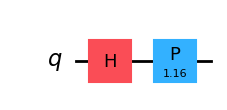

In [13]:
theta = np.random.uniform(0, np.pi/2)
qc4 = QuantumCircuit(1)
qc4.h(0)
qc4.p(theta,0)
display(qc4.draw("mpl"))


In [14]:
state4 = Statevector.from_instruction(qc4)
print("Random Phase Angle")
print(theta)


Random Phase Angle
1.1573518706952763


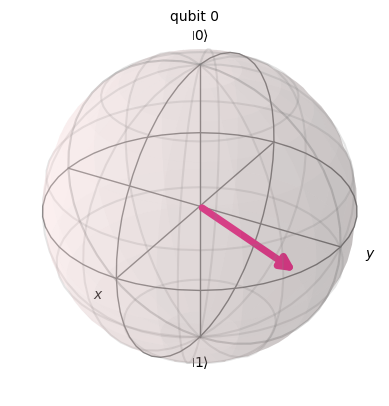

In [15]:
from qiskit.visualization import plot_bloch_multivector
from IPython.display import display
fig = plot_bloch_multivector(state4)
display(fig)


### Observation

The rotation angles θ and φ determine the position of the qubit on the Bloch Sphere.

Changing these values generates different quantum states while maintaining normalization.

This demonstrates how arbitrary quantum states can be prepared using rotation gates.

# Conclusion

The tutorial successfully demonstrated the representation of quantum states using state vectors and Dirac notation. Single-qubit and two-qubit systems were created using Qiskit, and their behavior was analyzed using circuit diagrams, probability distributions, and Bloch Sphere visualizations. The exercises illustrated superposition, phase changes, normalization, and arbitrary state preparation, providing a strong understanding of fundamental quantum computing concepts.

# Reflection Questions

### 1. Why must the sum of squared amplitudes always equal 1?

The squared amplitudes represent measurement probabilities, so their total must always equal 1.



### 2. How does the Bloch Sphere fail to represent multi-qubit entangled states?

The Bloch Sphere represents only one qubit. Multi-qubit entangled states are represented using Q-Sphere or state vectors.